---
jupyter: false
---

# Ratios and Musical Intervals

In [1]:
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#111111',
    'axes.facecolor': '#111111',
    'axes.edgecolor': '#444444',
    'axes.labelcolor': '#cccccc',
    'xtick.color': '#888888',
    'ytick.color': '#888888',
    'grid.color': '#333333',
    'text.color': '#cccccc',
    'figure.figsize': (10, 2.5),
})



## What is a Tone?

At its most basic, a *tone* is any periodic vibration repeating at a regular rate — a waveform cycling at some *frequency*. We measure frequency in **Hertz** (Hz), which simply means "cycles per second." A tone vibrating at 440 Hz completes 440 cycles every second — this is the standard tuning reference, the concert A above middle C.

The higher the frequency, the higher we perceive the pitch. The lower the frequency, the lower the pitch.

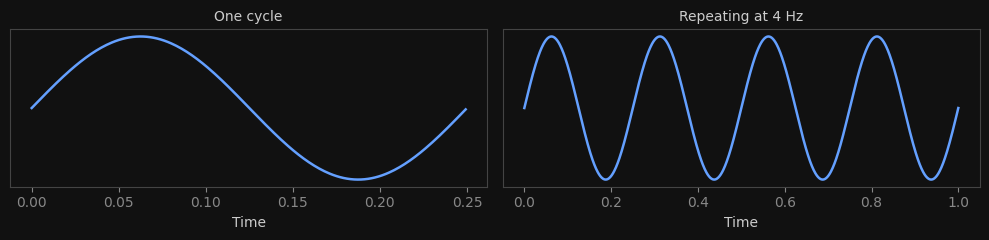

In [2]:
t = np.linspace(0, 1, 1000)
freq = 4

fig, axes = plt.subplots(1, 2, figsize=(10, 2.5))

axes[0].plot(t[:250], np.sin(2 * np.pi * freq * t[:250]), color='#64a0ff', linewidth=1.8)
axes[0].set_title('One cycle', fontsize=10)
axes[0].set_xlabel('Time')
axes[0].set_yticks([])

axes[1].plot(t, np.sin(2 * np.pi * freq * t), color='#64a0ff', linewidth=1.8)
axes[1].set_title(f'Repeating at {freq} Hz', fontsize=10)
axes[1].set_xlabel('Time')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

## Ratios as Intervals

Musical intervals arise from *ratios* between frequencies. If we take a frequency and *multiply* it by a ratio, we get a new frequency — and the relationship between those two frequencies is what we hear as an interval.

| Ratio | Interval | Example (from 440 Hz) |
|-------|----------|----------------------|
| 2/1 | Octave | 880 Hz |
| 3/2 | Perfect fifth | 660 Hz |
| 4/3 | Perfect fourth | ~587 Hz |
| 5/4 | Major third | 550 Hz |
| 6/5 | Minor third | 528 Hz |
| 5/3 | Major sixth | ~733 Hz |

These ratios are *simple* — their numerators and denominators are small integers. Simple ratios tend to produce intervals that sound *consonant* (stable, blending). More complex ratios produce intervals that sound more *dissonant* (tense, active).

An interval is a ratio, and combining intervals means multiplying ratios. A perfect fifth (3/2) followed by a major third (5/4) gives us 3/2 × 5/4 = 15/8 — a major seventh.

Let's see (and hear) what some of these look like when superimposed:

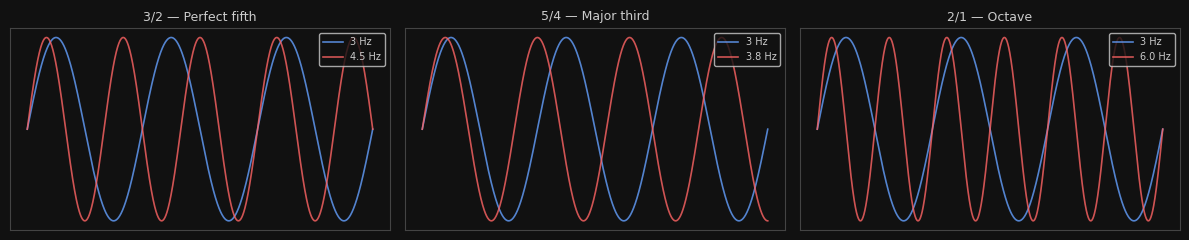

In [3]:
t = np.linspace(0, 1, 2000)
base = 3

intervals = [
    ('3/2 — Perfect fifth', Fraction(3, 2)),
    ('5/4 — Major third', Fraction(5, 4)),
    ('2/1 — Octave', Fraction(2, 1)),
]

fig, axes = plt.subplots(1, len(intervals), figsize=(12, 2.5))

for ax, (label, ratio) in zip(axes, intervals):
    f1, f2 = base, float(base * ratio)
    ax.plot(t, np.sin(2 * np.pi * f1 * t), color='#64a0ff', linewidth=1.2, alpha=0.8, label=f'{base} Hz')
    ax.plot(t, np.sin(2 * np.pi * f2 * t), color='#ff6464', linewidth=1.2, alpha=0.8, label=f'{f2:.1f} Hz')
    ax.set_title(label, fontsize=9)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

## Octave Equivalence

One ratio holds a special place: **2/1**, the octave. Multiplying any frequency by 2 produces a pitch that sounds like the "same note" but higher. Dividing by 2 gives the same note but lower.

Why? Look at what happens when we superimpose a frequency with its octave — the higher wave completes exactly 2 cycles for every 1 cycle of the lower wave. They align perfectly at every period boundary. This clean alignment is why octaves sound so similar that we perceive them as "the same note."

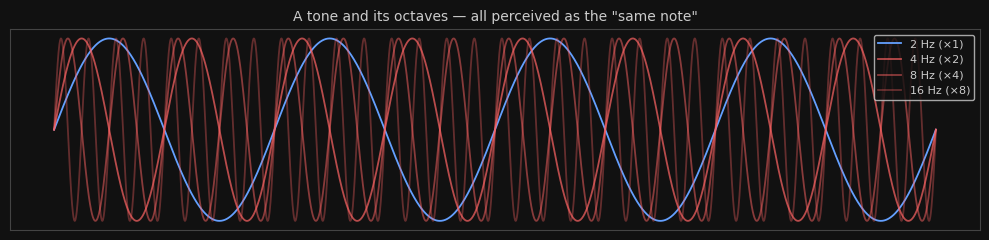

In [4]:
t = np.linspace(0, 2, 3000)
base = 2

fig, ax = plt.subplots(figsize=(10, 2.5))
for octave, alpha in [(1, 1.0), (2, 0.7), (4, 0.5), (8, 0.35)]:
    f = base * octave
    color = '#64a0ff' if octave == 1 else '#ff6464'
    ax.plot(t, np.sin(2 * np.pi * f * t), color=color, linewidth=1.3, alpha=alpha, label=f'{f} Hz (×{octave})')

ax.set_title('A tone and its octaves — all perceived as the "same note"', fontsize=10)
ax.set_yticks([])
ax.set_xticks([])
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

This property — that frequencies related by powers of 2 are perceived as equivalent — is called **octave equivalence**. It's one of the few near-universals in music across world cultures: 440 Hz, 880 Hz, 220 Hz, and 1760 Hz are all perceived as "A."

Mathematically, this means we can always multiply or divide a ratio by powers of 2 (2/1, 4/1, 1/2, 1/4, ...) and arrive at an "equivalent" pitch. This will become important when we start working with lattices and harmonic spaces.

A brief aside: the term **equave** generalizes this concept beyond octaves — where some interval *other* than 2/1 serves as the equivalence boundary. We won't dwell on this now, but it's worth knowing the term exists. Most of what follows will assume octave equivalence (2/1).

---

Tones as frequencies, intervals as ratios, octaves as powers of 2 — these are the building blocks. In the next notebooks, we'll see how these relationships can be organized spatially in **tone lattices**.